# Inspeção de Qualidade

## 1. Conhecendo o Dataset

### Classes
- def_front: peças defeituosas
- ok_front: peças em perfeito estado

### Formato das imagens
- .jpeg

### Observações visuais
- As peças defeituosas apresentam partes tortas, buracos e riscos.
- As peças da classe ok_front não apresentam essas irregularidades visíveis.
  
- Amostras selecionadas:

Imagem cast_ak_0_9658.jpeg:
Classe: ok_front
Motivo: peça em perfeito estado utilizada como referência.

Imagem cast_def_0_122.jpeg:
Classe: def_front
Motivo: apresenta defeito claramente visível.

Imagem cast_def_0_9643.jpeh:
Classe: def_front
Motivo: apresenta defeito mais discreto.



## 2. Análise Exploratória com OpenCV

### 3.1 Importação das bibliotecas

Nesta etapa são importadas as bibliotecas necessárias para carregar,
processar e visualizar as imagens utilizadas na análise exploratória.

In [2]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path


In [3]:
pasta_atual = Path.cwd()

if (pasta_atual / "dataset").exists():
    raiz_projeto = pasta_atual
elif (pasta_atual.parent / "dataset").exists():
    raiz_projeto = pasta_atual.parent
else:
    raise FileNotFoundError("Não foi possível localizar a pasta dataset.")

print("Raiz do projeto:", raiz_projeto)

Raiz do projeto: c:\Users\migue\OneDrive\Documentos\CURSO-SCTEC\projeto_inspecao_qualidade


In [4]:
caminho_imagem = (
    raiz_projeto
    / "dataset"
    / "casting_512x512"
    / "def_front"
    / "cast_def_0_122.jpeg"
)

print(caminho_imagem)

c:\Users\migue\OneDrive\Documentos\CURSO-SCTEC\projeto_inspecao_qualidade\dataset\casting_512x512\def_front\cast_def_0_122.jpeg


In [5]:
print("Arquivo encontrado:", caminho_imagem.exists())

Arquivo encontrado: True


In [6]:
imagem_bgr = cv2.imread(str(caminho_imagem))

In [7]:
if imagem_bgr is None:
    raise ValueError("A imagem não pôde ser carregada.")

print("Imagem carregada com sucesso.")

Imagem carregada com sucesso.


In [8]:
print("Formato da imagem:", imagem_bgr.shape)

Formato da imagem: (512, 512, 3)


In [9]:
imagem_rgb = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2RGB)

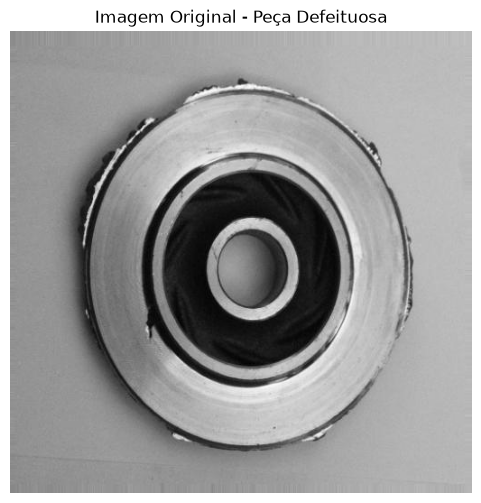

In [10]:
plt.figure(figsize=(6, 6))

plt.imshow(imagem_rgb)

plt.title("Imagem Original - Peça Defeituosa")

plt.axis("off")

plt.show()

### 3.2 Imagem Original

Inicialmente, a imagem defeituosa é carregada sem alterações para servir
como referência durante o processamento. Dessa forma, será possível
comparar a imagem original com os resultados obtidos nas etapas seguintes.

In [11]:
imagem_gray = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2GRAY)

In [12]:
print("Formato original:", imagem_bgr.shape)
print("Formato grayscale:", imagem_gray.shape)

Formato original: (512, 512, 3)
Formato grayscale: (512, 512)


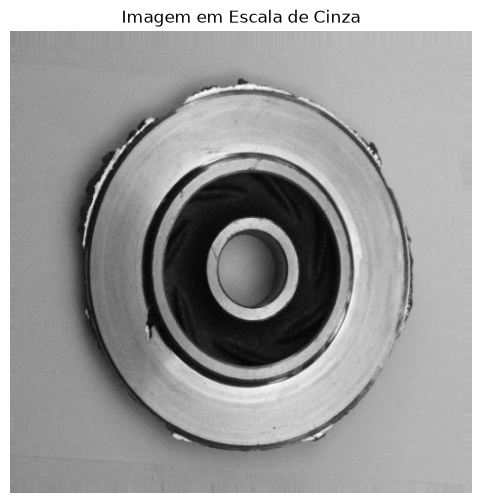

In [13]:
plt.figure(figsize=(6, 6))

plt.imshow(imagem_gray, cmap="gray")

plt.title("Imagem em Escala de Cinza")

plt.axis("off")

plt.show()

### 3.3 Conversão para Grayscale

A imagem foi convertida para escala de cinza com o objetivo de reduzir
a complexidade da informação visual. Nesta representação, o processamento
passa a considerar principalmente as diferenças de intensidade entre os
pixels, facilitando etapas posteriores como limiarização e detecção de bordas.

In [14]:
imagem_blur = cv2.GaussianBlur(
    imagem_gray,
    (5, 5),
    0
)

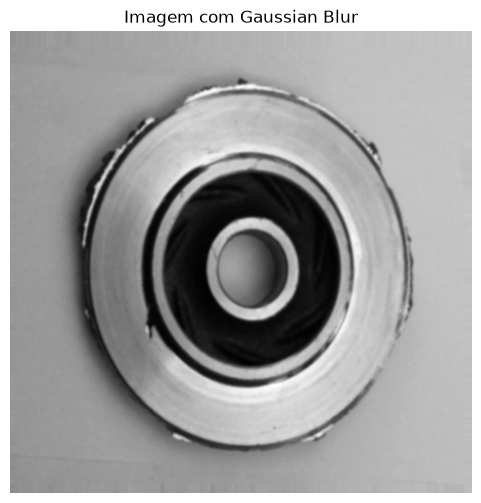

In [15]:
plt.figure(figsize=(6, 6))

plt.imshow(imagem_blur, cmap="gray")

plt.title("Imagem com Gaussian Blur")

plt.axis("off")

plt.show()

### 3.4 Suavização com Gaussian Blur

Após a conversão para escala de cinza, foi aplicado o Gaussian Blur
para reduzir pequenas variações e ruídos presentes na superfície da imagem.

A suavização é importante porque ruídos podem ser interpretados
incorretamente como bordas nas etapas seguintes. O objetivo é reduzir
esses detalhes sem eliminar as características associadas aos defeitos.

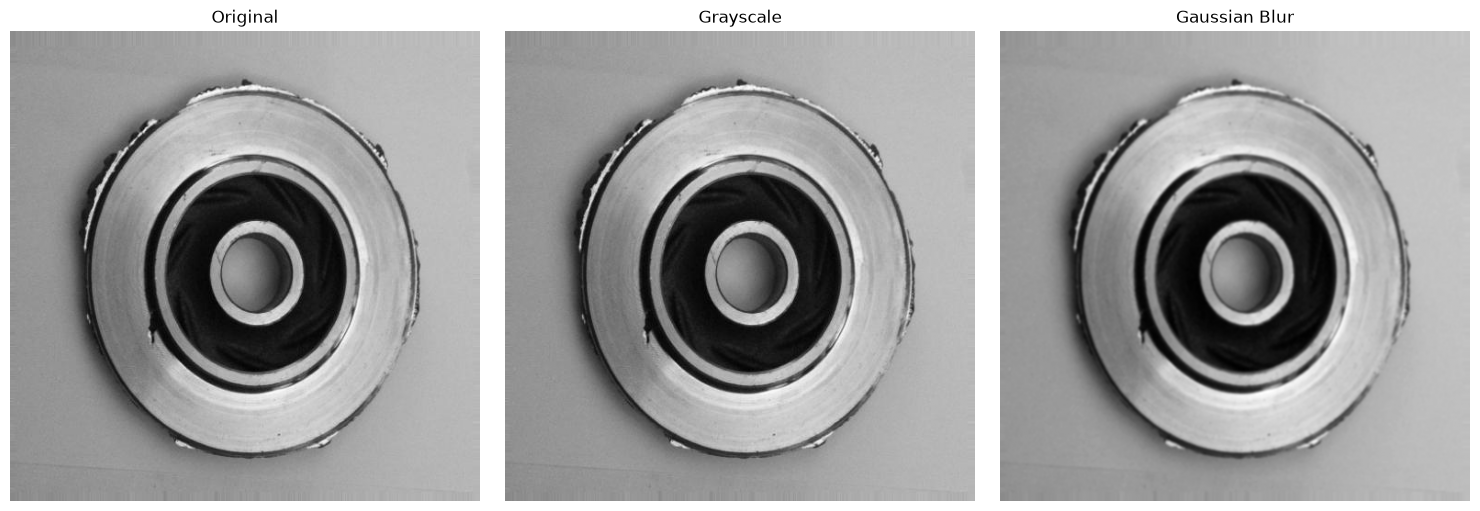

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(imagem_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(imagem_gray, cmap="gray")
axes[1].set_title("Grayscale")
axes[1].axis("off")

axes[2].imshow(imagem_blur, cmap="gray")
axes[2].set_title("Gaussian Blur")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Observação do resultado

Após a conversão para escala de cinza, os detalhes de intensidade da
superfície permaneceram visíveis. Com a aplicação do Gaussian Blur,
pequenas variações da textura foram suavizadas, enquanto o defeito
principal da peça continuou perceptível.

In [17]:
blur_3 = cv2.GaussianBlur(imagem_gray, (3, 3), 0)
blur_5 = cv2.GaussianBlur(imagem_gray, (5, 5), 0)
blur_7 = cv2.GaussianBlur(imagem_gray, (7, 7), 0)

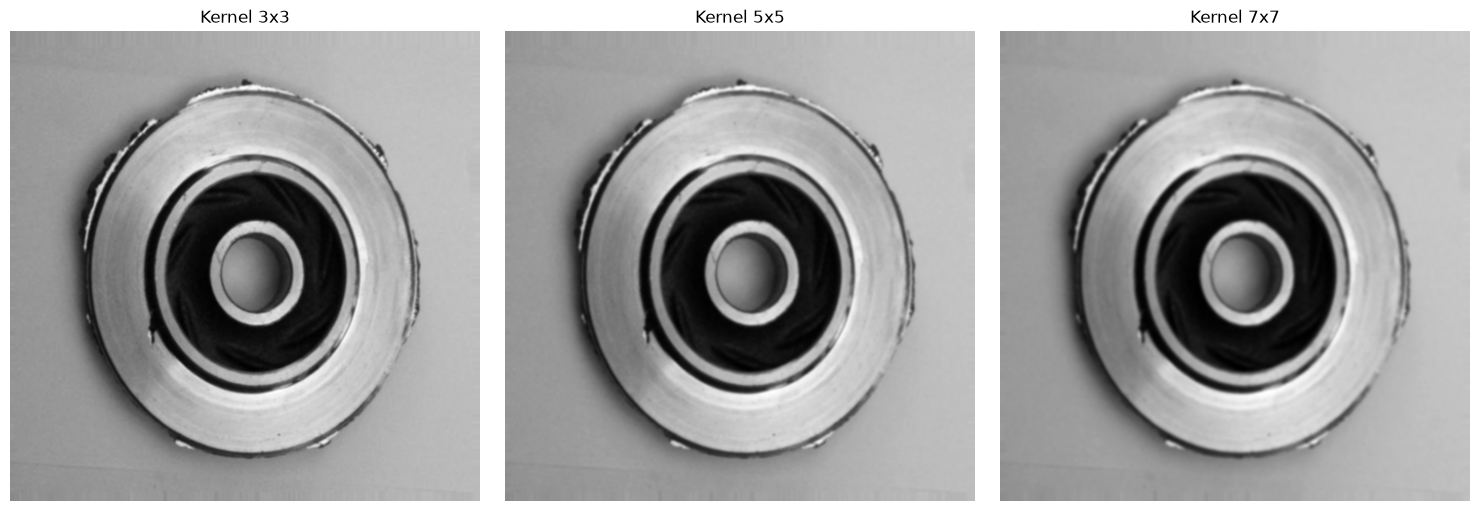

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(blur_3, cmap="gray")
axes[0].set_title("Kernel 3x3")
axes[0].axis("off")

axes[1].imshow(blur_5, cmap="gray")
axes[1].set_title("Kernel 5x5")
axes[1].axis("off")

axes[2].imshow(blur_7, cmap="gray")
axes[2].set_title("Kernel 7x7")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [19]:
pasta_resultados = raiz_projeto / "resultados"

pasta_resultados.mkdir(exist_ok=True)

In [20]:
cv2.imwrite(
    str(pasta_resultados / "defeito_grayscale.jpeg"),
    imagem_gray
)

cv2.imwrite(
    str(pasta_resultados / "defeito_gaussian_blur.jpeg"),
    imagem_blur
)

True

## 4. Destaque de Características

Nesta etapa serão utilizadas técnicas de limiarização, detecção de bordas
e operações morfológicas com o objetivo de evidenciar irregularidades
presentes na superfície da peça.

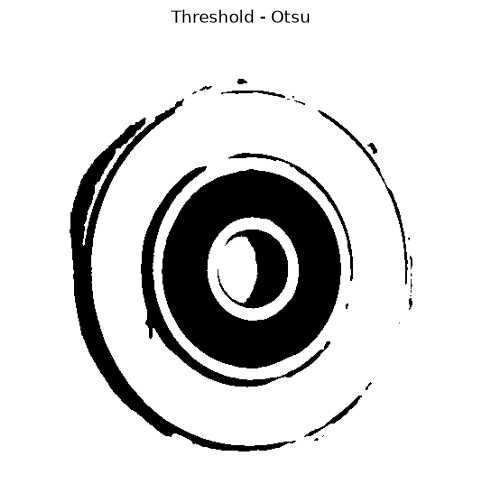

In [24]:
_, threshold_otsu = cv2.threshold(
    imagem_blur,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.figure(figsize=(6, 6))
plt.imshow(threshold_otsu, cmap="gray")
plt.title("Threshold - Otsu")
plt.axis("off")
plt.show()

In [28]:
valor_limite = 120

_, imagem_threshold = cv2.threshold(
    imagem_blur,
    valor_limite,
    255,
    cv2.THRESH_BINARY
)

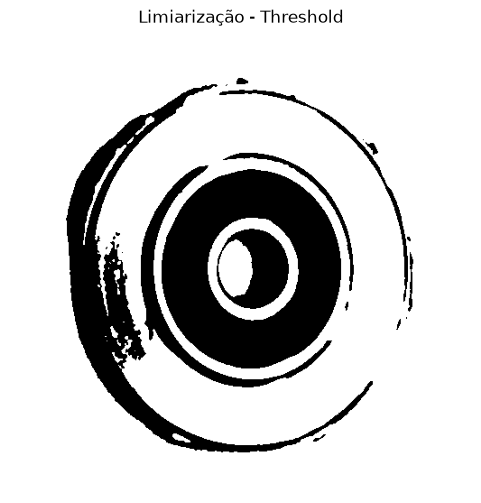

In [29]:
plt.figure(figsize=(6, 6))

plt.imshow(imagem_threshold, cmap="gray")
plt.title("Limiarização - Threshold")
plt.axis("off")

plt.show()

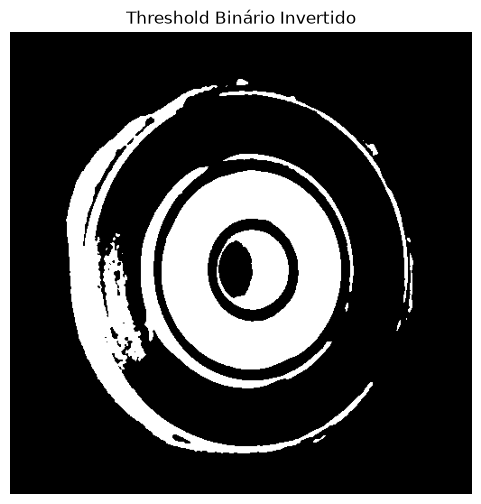

In [30]:
_, threshold_invertido = cv2.threshold(
    imagem_blur,
    120,
    255,
    cv2.THRESH_BINARY_INV
)

plt.figure(figsize=(6, 6))
plt.imshow(threshold_invertido, cmap="gray")
plt.title("Threshold Binário Invertido")
plt.axis("off")
plt.show()

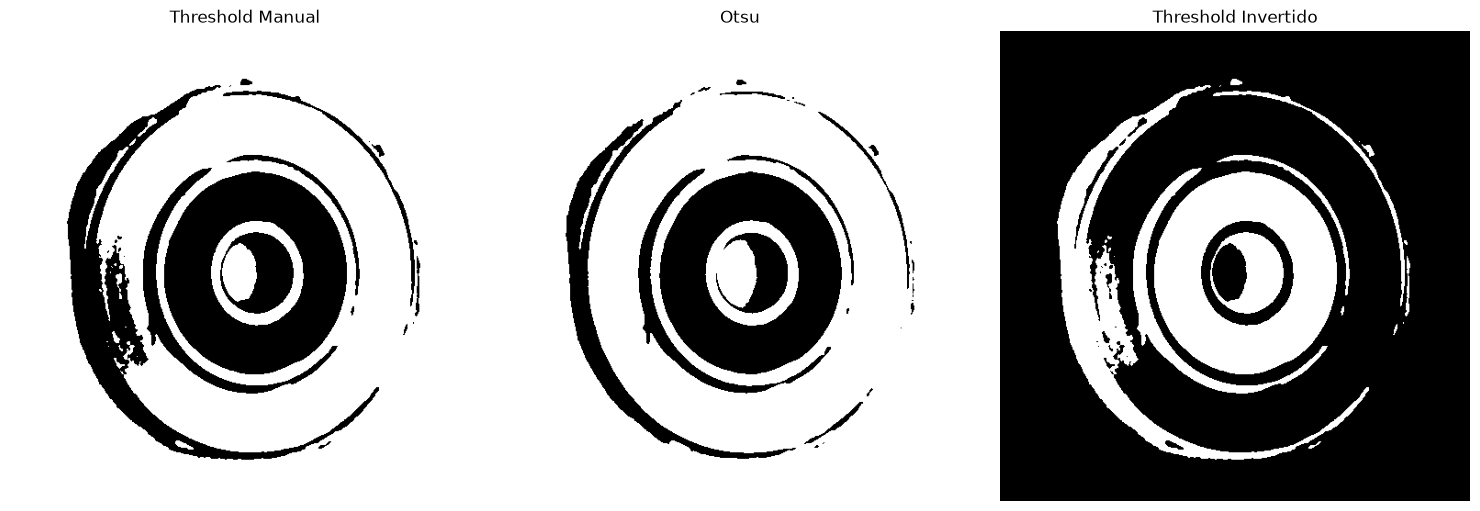

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(imagem_threshold, cmap="gray")
axes[0].set_title("Threshold Manual")
axes[0].axis("off")

axes[1].imshow(threshold_otsu, cmap="gray")
axes[1].set_title("Otsu")
axes[1].axis("off")

axes[2].imshow(threshold_invertido, cmap="gray")
axes[2].set_title("Threshold Invertido")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# observações threshold
O Threshold manual e o método de Otsu apresentaram resultados semelhantes, evidenciando principalmente as regiões estruturais da peça. A limiarização não conseguiu isolar claramente os defeitos, pois as variações naturais de intensidade e a geometria circular também foram destacadas. Por esse motivo, a próxima etapa utilizará detecção de bordas para tentar evidenciar melhor riscos, buracos e irregularidades.

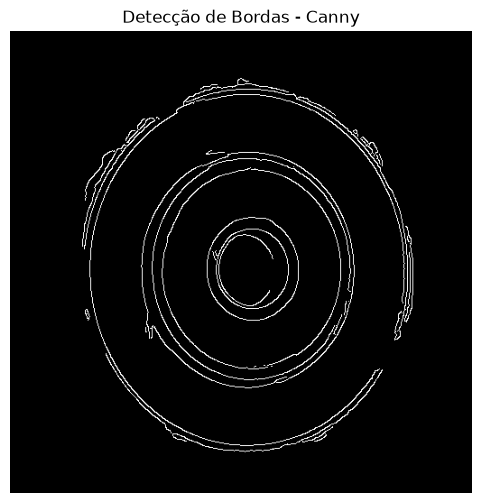

In [32]:
imagem_canny = cv2.Canny(
    imagem_blur,
    50,
    150
)

plt.figure(figsize=(6, 6))
plt.imshow(imagem_canny, cmap="gray")
plt.title("Detecção de Bordas - Canny")
plt.axis("off")
plt.show()

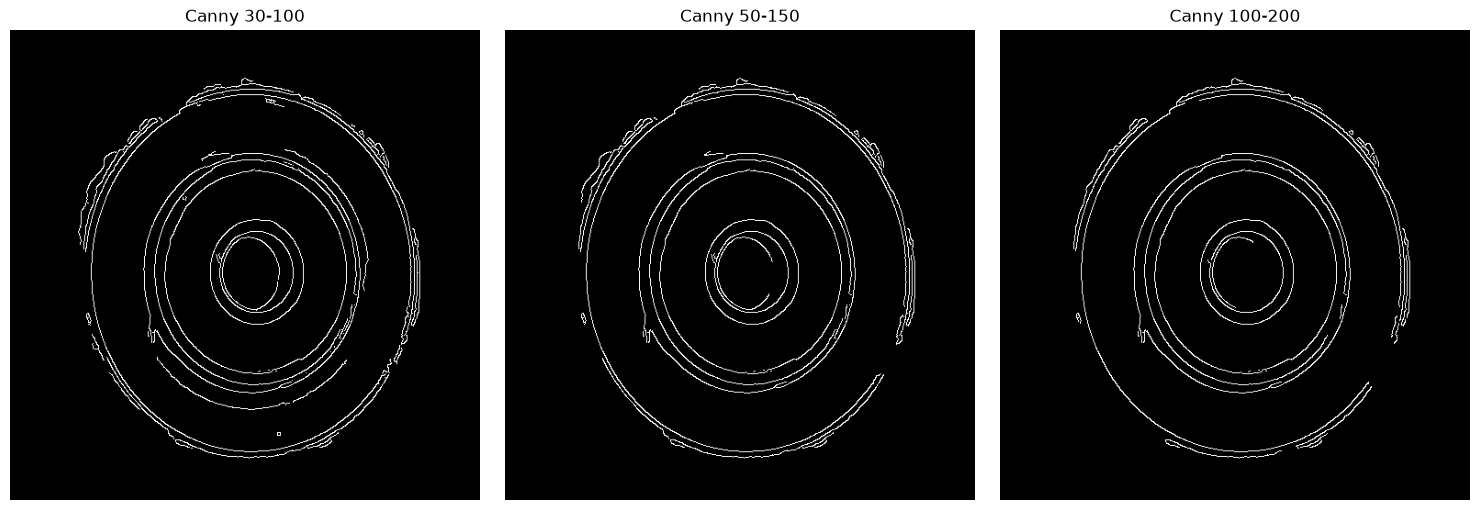

In [33]:
canny_30_100 = cv2.Canny(imagem_blur, 30, 100)
canny_50_150 = cv2.Canny(imagem_blur, 50, 150)
canny_100_200 = cv2.Canny(imagem_blur, 100, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(canny_30_100, cmap="gray")
axes[0].set_title("Canny 30-100")
axes[0].axis("off")

axes[1].imshow(canny_50_150, cmap="gray")
axes[1].set_title("Canny 50-150")
axes[1].axis("off")

axes[2].imshow(canny_100_200, cmap="gray")
axes[2].set_title("Canny 100-200")
axes[2].axis("off")

plt.tight_layout()
plt.show()

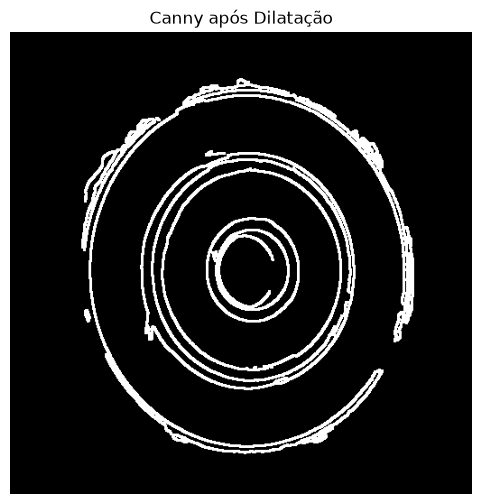

In [34]:
import numpy as np

kernel = np.ones((3, 3), np.uint8)

imagem_dilatada = cv2.dilate(
    imagem_canny,
    kernel,
    iterations=1
)


plt.figure(figsize=(6, 6))
plt.imshow(imagem_dilatada, cmap="gray")
plt.title("Canny após Dilatação")
plt.axis("off")
plt.show()






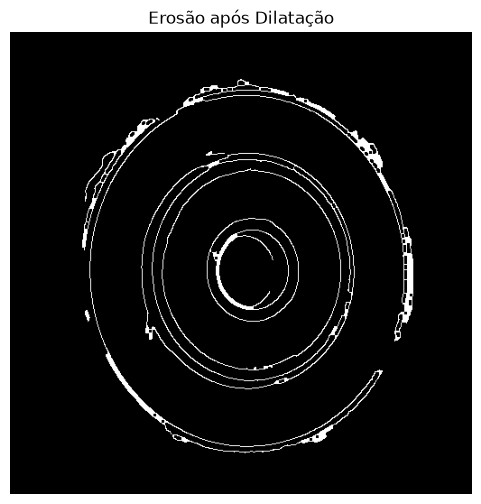

In [35]:
imagem_erodida = cv2.erode(
    imagem_dilatada,
    kernel,
    iterations=1
)

plt.figure(figsize=(6, 6))

plt.imshow(imagem_erodida, cmap="gray")
plt.title("Erosão após Dilatação")
plt.axis("off")

plt.show()

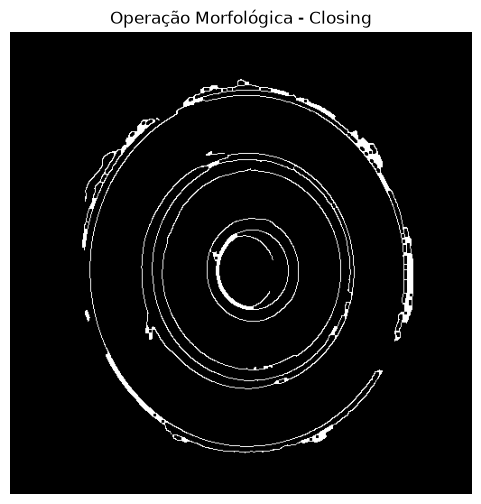

In [36]:
imagem_closing = cv2.morphologyEx(
    imagem_canny,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=1
)
plt.figure(figsize=(6, 6))

plt.imshow(imagem_closing, cmap="gray")
plt.title("Operação Morfológica - Closing")
plt.axis("off")

plt.show()

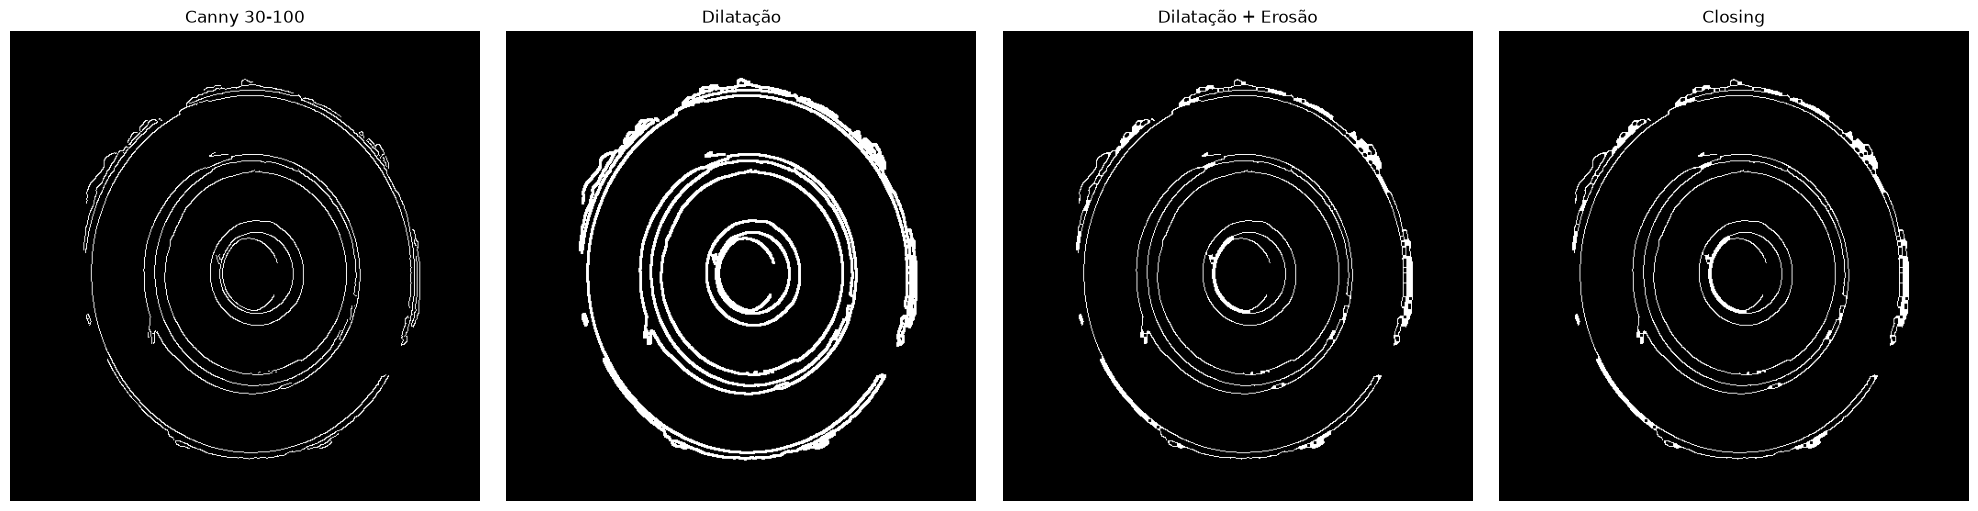

In [37]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(imagem_canny, cmap="gray")
axes[0].set_title("Canny 30-100")
axes[0].axis("off")

axes[1].imshow(imagem_dilatada, cmap="gray")
axes[1].set_title("Dilatação")
axes[1].axis("off")

axes[2].imshow(imagem_erodida, cmap="gray")
axes[2].set_title("Dilatação + Erosão")
axes[2].axis("off")

axes[3].imshow(imagem_closing, cmap="gray")
axes[3].set_title("Closing")
axes[3].axis("off")

plt.tight_layout()
plt.show()

### 4.3 Operações Morfológicas

Após a detecção de bordas com Canny, foram testadas operações
morfológicas para avaliar se pequenas interrupções nos contornos
poderiam ser conectadas ou reforçadas.

Foram avaliadas dilatação, erosão e a operação Closing.

A dilatação tornou as bordas mais espessas, porém também aumentou
excessivamente algumas regiões, prejudicando a visualização dos detalhes.

A erosão foi aplicada após a dilatação para reduzir esse efeito.
O Closing também foi avaliado com o objetivo de conectar pequenas
descontinuidades mantendo melhor a estrutura das bordas.

eu escolheria a A combinação de dilatação e erosão e a operação Closing produziram resultados mais equilibrados. 

In [38]:
def processar_imagem(caminho):
    # Carrega a imagem
    imagem_bgr = cv2.imread(str(caminho))

    if imagem_bgr is None:
        raise ValueError(f"Não foi possível carregar: {caminho}")

    # BGR -> RGB para visualização
    imagem_rgb = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2RGB)

    # Escala de cinza
    imagem_gray = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2GRAY)

    # Suavização
    imagem_blur = cv2.GaussianBlur(imagem_gray, (5, 5), 0)

    # Threshold automático
    _, imagem_threshold = cv2.threshold(
        imagem_blur,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Canny escolhido após os testes
    imagem_canny = cv2.Canny(imagem_blur, 30, 100)

    # Kernel morfológico
    kernel = np.ones((3, 3), np.uint8)

    # Dilatação
    imagem_dilatada = cv2.dilate(
        imagem_canny,
        kernel,
        iterations=1
    )

    # Closing
    imagem_closing = cv2.morphologyEx(
        imagem_canny,
        cv2.MORPH_CLOSE,
        kernel
    )

    return {
        "original": imagem_rgb,
        "gray": imagem_gray,
        "blur": imagem_blur,
        "threshold": imagem_threshold,
        "canny": imagem_canny,
        "dilatacao": imagem_dilatada,
        "closing": imagem_closing
    }

True
True
True


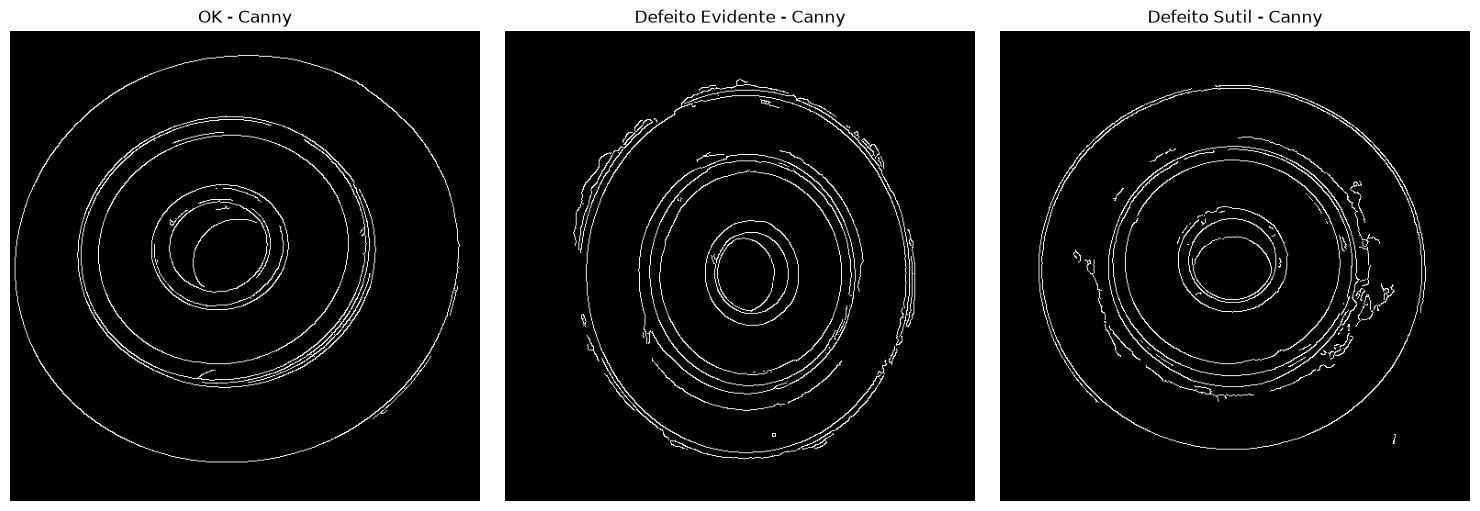

In [40]:
pasta_ok = raiz_projeto / "dataset" / "casting_512x512" / "ok_front"
pasta_def = raiz_projeto / "dataset" / "casting_512x512" / "def_front"

caminho_ok = pasta_ok / "cast_ok_0_9658.jpeg"

caminho_def_evidente = pasta_def / "cast_def_0_122.jpeg"

caminho_def_sutil = pasta_def / "cast_def_0_9643.jpeg"

print(caminho_ok.exists())
print(caminho_def_evidente.exists())
print(caminho_def_sutil.exists())

resultado_ok = processar_imagem(caminho_ok)

resultado_def_evidente = processar_imagem(caminho_def_evidente)

resultado_def_sutil = processar_imagem(caminho_def_sutil)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(resultado_ok["canny"], cmap="gray")
axes[0].set_title("OK - Canny")
axes[0].axis("off")

axes[1].imshow(resultado_def_evidente["canny"], cmap="gray")
axes[1].set_title("Defeito Evidente - Canny")
axes[1].axis("off")

axes[2].imshow(resultado_def_sutil["canny"], cmap="gray")
axes[2].set_title("Defeito Sutil - Canny")
axes[2].axis("off")

plt.tight_layout()
plt.show()


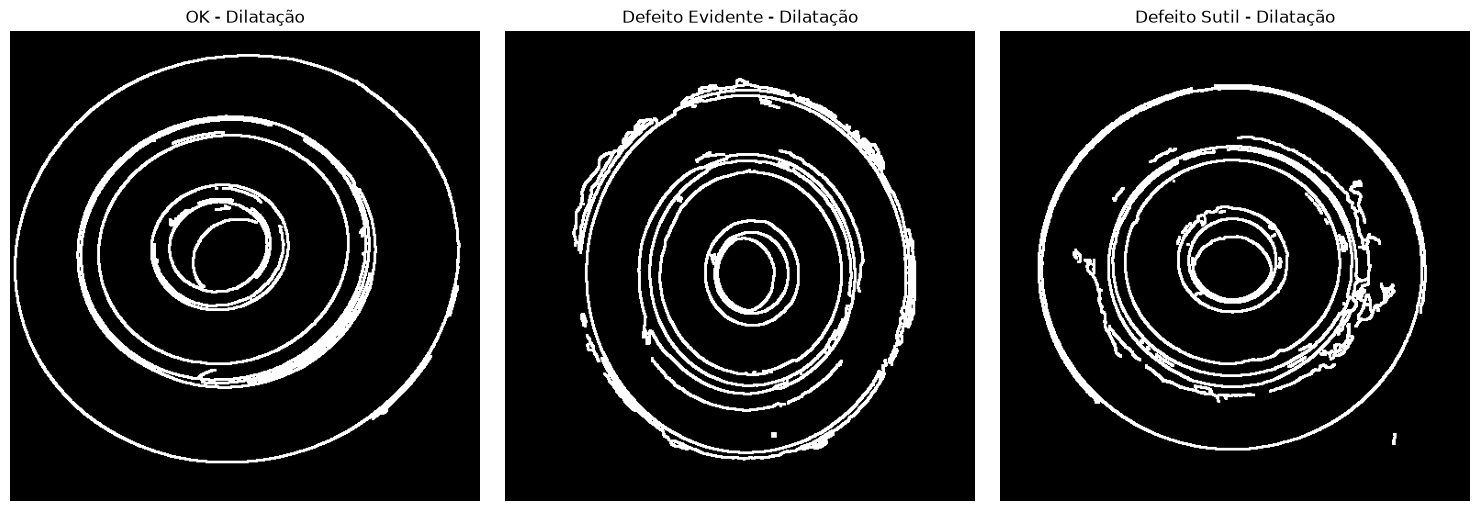

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(resultado_ok["dilatacao"], cmap="gray")
axes[0].set_title("OK - Dilatação")
axes[0].axis("off")

axes[1].imshow(resultado_def_evidente["dilatacao"], cmap="gray")
axes[1].set_title("Defeito Evidente - Dilatação")
axes[1].axis("off")

axes[2].imshow(resultado_def_sutil["dilatacao"], cmap="gray")
axes[2].set_title("Defeito Sutil - Dilatação")
axes[2].axis("off")

plt.tight_layout()
plt.show()

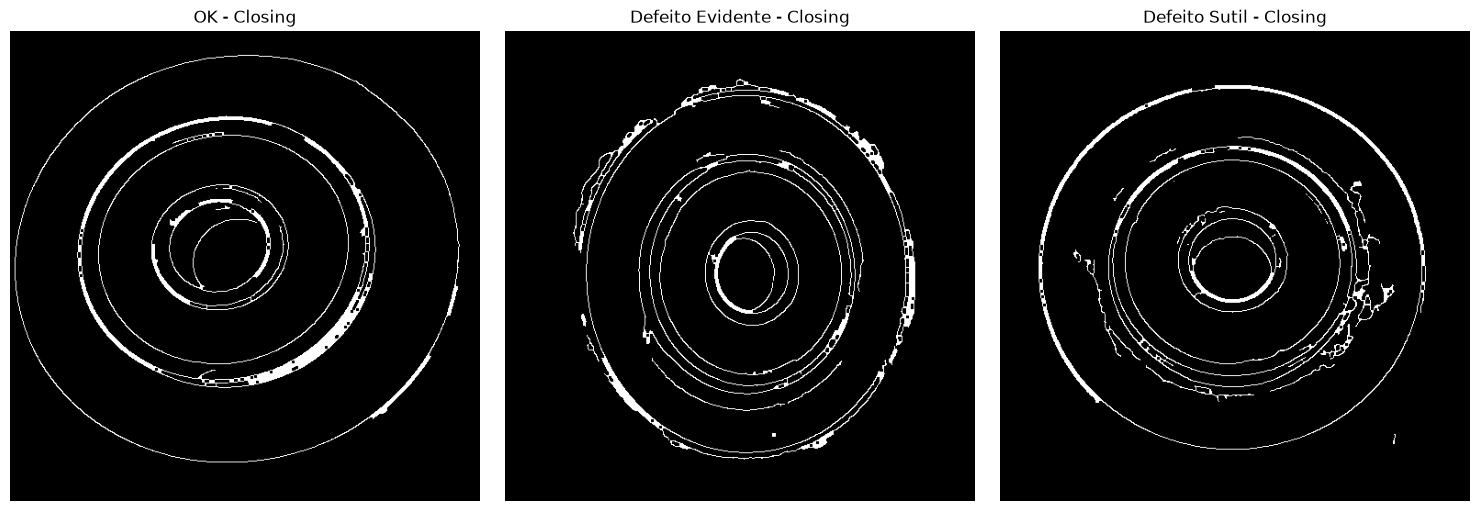

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(resultado_ok["closing"], cmap="gray")
axes[0].set_title("OK - Closing")
axes[0].axis("off")

axes[1].imshow(resultado_def_evidente["closing"], cmap="gray")
axes[1].set_title("Defeito Evidente - Closing")
axes[1].axis("off")

axes[2].imshow(resultado_def_sutil["closing"], cmap="gray")
axes[2].set_title("Defeito Sutil - Closing")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Conclusão da etapa de morfologia

Após comparar as operações morfológicas nas três amostras selecionadas,
o Closing apresentou o resultado mais equilibrado.

Na peça sem defeito, a estrutura das bordas permaneceu relativamente
organizada. Já nas peças defeituosas, o Closing ajudou a conectar pequenas
descontinuidades e tornar algumas irregularidades mais evidentes.

Por esse motivo, o Closing com kernel 3x3 foi escolhido como a operação
morfológica principal do pipeline de análise exploratória.

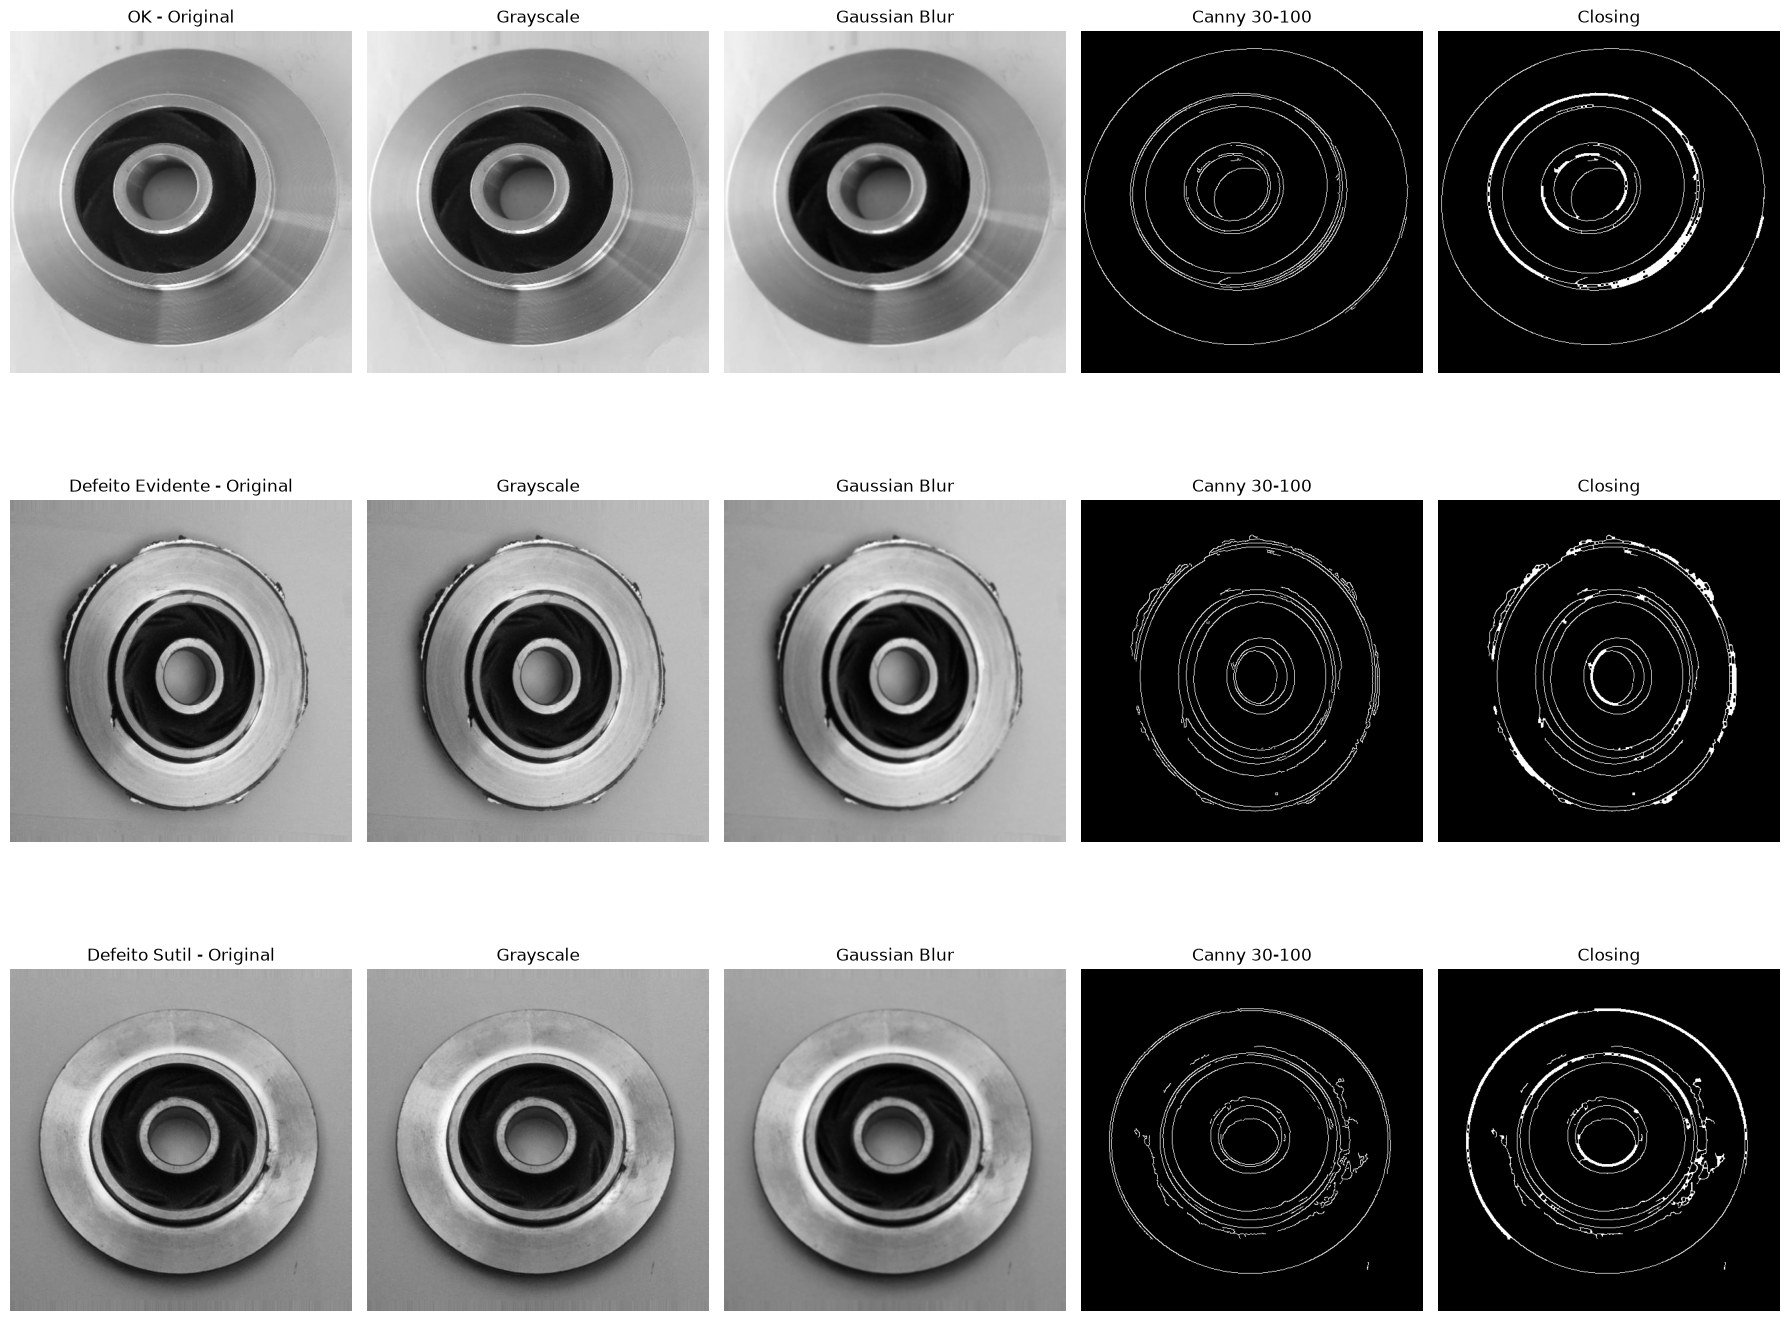

In [43]:
fig, axes = plt.subplots(3, 5, figsize=(18, 15))

resultados = [
    ("OK", resultado_ok),
    ("Defeito Evidente", resultado_def_evidente),
    ("Defeito Sutil", resultado_def_sutil)
]

for linha, (nome, resultado) in enumerate(resultados):

    axes[linha, 0].imshow(resultado["original"])
    axes[linha, 0].set_title(f"{nome} - Original")

    axes[linha, 1].imshow(resultado["gray"], cmap="gray")
    axes[linha, 1].set_title("Grayscale")

    axes[linha, 2].imshow(resultado["blur"], cmap="gray")
    axes[linha, 2].set_title("Gaussian Blur")

    axes[linha, 3].imshow(resultado["canny"], cmap="gray")
    axes[linha, 3].set_title("Canny 30-100")

    axes[linha, 4].imshow(resultado["closing"], cmap="gray")
    axes[linha, 4].set_title("Closing")

    for coluna in range(5):
        axes[linha, coluna].axis("off")

plt.tight_layout()
plt.show()

### Conclusão da análise exploratória com OpenCV

O pré-processamento permitiu observar como diferentes técnicas respondem
às características das peças.

A conversão para escala de cinza simplificou a informação visual, enquanto
o Gaussian Blur reduziu pequenas variações da superfície.

A limiarização conseguiu separar regiões de intensidade, porém não isolou
claramente os defeitos devido à própria geometria da peça.

A detecção de bordas com Canny apresentou melhores resultados utilizando
os limiares 30 e 100. Por fim, o Closing ajudou a conectar pequenas
descontinuidades nas bordas e apresentou o comportamento mais consistente
entre as amostras analisadas.

## 5. Carregamento do Dataset e Data Augmentation

Nesta etapa, o dataset completo será carregado automaticamente com
TensorFlow/Keras e dividido em conjuntos de treinamento e validação.

Também serão aplicadas técnicas de Data Augmentation para simular
variações que podem ocorrer durante uma inspeção industrial.

In [46]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

diretorio_dataset = (
    raiz_projeto
    / "dataset"
    / "casting_512x512"
)

print(diretorio_dataset)
print("Dataset encontrado:", diretorio_dataset.exists())

imagens_def = list((diretorio_dataset / "def_front").glob("*.jpeg"))
imagens_ok = list((diretorio_dataset / "ok_front").glob("*.jpeg"))

print("Imagens defeituosas:", len(imagens_def))
print("Imagens OK:", len(imagens_ok))
print("Total:", len(imagens_def) + len(imagens_ok))

c:\Users\migue\OneDrive\Documentos\CURSO-SCTEC\projeto_inspecao_qualidade\dataset\casting_512x512
Dataset encontrado: True
Imagens defeituosas: 781
Imagens OK: 519
Total: 1300


In [47]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 123